In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 1. loading data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/FC26_20250921.csv')

In [ ]:
df.shape

(18405, 110)

In [ ]:
df.head(3)

,player_id,player_url,fifa_version,fifa_update,fifa_update_date,short_name,long_name,player_positions,overall,potential,...,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,gk,player_face_url
0,252371,/player/252371/jude-bellingham/260004/,26,4,2025-09-19,J. Bellingham,Jude Victor William Bellingham,"CAM, CM",90,94,...,85+3,85+3,83+3,82+3,81+3,81+3,81+3,82+3,18+3,https://cdn.sofifa.net/players/252/371/26_120.png
1,239053,/player/239053/federico-valverde/260004/,26,4,2025-09-19,F. Valverde,Federico Santiago Valverde Dipetta,"CM, CDM, RB",89,90,...,87+3,87+3,86+3,86+3,83+3,83+3,83+3,86+3,18+3,https://cdn.sofifa.net/players/239/053/26_120.png
2,212622,/player/212622/joshua-kimmich/260004/,26,4,2025-09-19,J. Kimmich,Joshua Walter Kimmich,"CDM, RB, CM",89,89,...,87+2,87+2,86+3,85+3,82+3,82+3,82+3,85+3,21+3,https://cdn.sofifa.net/players/212/622/26_120.png


In [ ]:
cols_to_use=[
 'long_name', 'player_positions', 'overall', 'potential',
 'value_eur', 'wage_eur',
 'age', 'height_cm', 'weight_kg', 'league_name',
 'league_level', 'club_name', 'club_position',
 'club_contract_valid_until_year',
 'nationality_name', 'nation_position',
 'preferred_foot',
 'weak_foot', 'skill_moves', 'international_reputation',
 'work_rate', 'release_clause_eur', 'player_tags', 'player_traits',
 'pace', 'shooting', 'passing', 'dribbling',
 'defending', 'physic', 'attacking_crossing',
 'attacking_finishing', 'attacking_heading_accuracy',
 'attacking_short_passing',
 'attacking_volleys', 'skill_dribbling',
 'skill_curve', 'skill_fk_accuracy', 'skill_long_passing', 'skill_ball_control', 'movement_acceleration', 'movement_sprint_speed', 'movement_agility', 'movement_reactions', 'movement_balance', 'power_shot_power', 'power_jumping', 'power_stamina', 'power_strength', 'power_long_shots', 'mentality_aggression', 'mentality_interceptions',
 'mentality_positioning','mentality_vision',
 'mentality_penalties','mentality_composure','defending_marking_awareness','defending_standing_tackle','defending_sliding_tackle',
 ]

meta_columns = [
    'short_name', 'long_name', 'player_positions', 'club_name',
    'league_name', 'league_level', 'nationality_name',
    'club_position', 'nation_position', 'work_rate',
    'body_type', 'real_face', 'age' , 'overall' , 'potential'
]

df_selected=df[cols_to_use]

df_meta=df[meta_columns]

In [ ]:
df_selected.head(3)

,long_name,player_positions,overall,potential,value_eur,wage_eur,age,height_cm,weight_kg,league_name,...,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle
0,Jude Victor William Bellingham,"CAM, CM",90,94,174500000,320000,22,186,75,La Liga,...,87,85,82,91,90,74,90,77,79,77
1,Federico Santiago Valverde Dipetta,"CM, CDM, RB",89,90,120500000,340000,26,182,74,La Liga,...,91,81,86,86,86,59,84,82,87,86
2,Joshua Walter Kimmich,"CDM, RB, CM",89,89,86000000,140000,30,177,75,Bundesliga,...,83,89,85,78,86,71,86,82,86,85


#### making a cell for only primary positions

In [ ]:
df_selected['primary_position'] = df_selected['player_positions'].str.split(',').str[0].str.strip()
df_meta['primary_position'] = df_meta['player_positions'].str.split(',').str[0].str.strip()
df_selected.drop('player_positions', axis=1, inplace=True)

In [ ]:
df_selected['contract_remaining_years']=df_selected['club_contract_valid_until_year']-2025
df_selected.drop('club_contract_valid_until_year' , axis=1 , inplace=True)

## 2. Handling NULL values

In [ ]:
# seeing only null values
null_df=df_selected.isnull().sum()[df_selected.isnull().sum()>0]
null_df=pd.DataFrame(null_df)
null_df.columns=['Missing Values']
null_df['Percentage %']=null_df['Missing Values']/df_selected.shape[0]*100
null_df

,Missing Values,Percentage %
league_name,89,0.483564
league_level,89,0.483564
club_name,89,0.483564
club_position,89,0.483564
nation_position,17677,96.044553
work_rate,18405,100.000000
release_clause_eur,1434,7.791361
player_tags,17455,94.838359
player_traits,10789,58.619940
pace,2062,11.203477


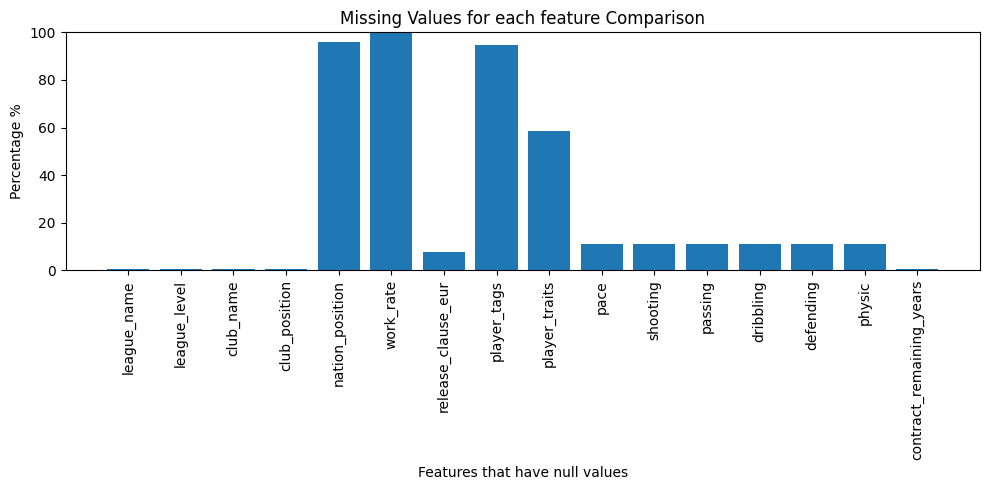

In [ ]:
plt.figure(figsize=(10,5))
plt.bar(
    x=null_df.index,
    height=null_df['Percentage %'],

)
plt.title("Missing Values for each feature Comparison")
plt.xlabel("Features that have null values")
plt.ylabel("Percentage %")
plt.xticks(rotation=90)
plt.tight_layout()
plt.ylim(0,100)
plt.show()

In [ ]:
df_selected.drop(['nation_position' , 'work_rate' , 'player_tags' , 'player_traits'] , axis=1 , inplace=True)

In [ ]:
df_selected.isnull().sum()

,0
long_name,0
overall,0
potential,0
value_eur,0
wage_eur,0
age,0
height_cm,0
weight_kg,0
league_name,89
league_level,89


In [ ]:
cols_to_discover=['release_clause_eur' , 'pace' , 'shooting' , 'passing', 'dribbling' , 'defending' , 'physic']
df_selected[df_selected['pace'].isnull()].sample(3)

,long_name,overall,potential,value_eur,wage_eur,age,height_cm,weight_kg,league_name,league_level,...,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle,primary_position,contract_remaining_years
17972,Yan Bingliang闫炳良,50,55,50000,800,25,197,92,Super League,1.0,...,13,13,26,13,32,12,20,16,GK,1.0
17480,Joshua Oluwayemi,60,67,425000,500,24,185,82,A-League Men,1.0,...,9,5,42,12,34,5,12,10,GK,1.0
15994,Lucas Estella Perri,81,85,27000000,44000,27,197,98,Premier League,1.0,...,25,12,65,19,44,10,18,14,GK,4.0


#### seems like the missing attributes belong to GKs

In [ ]:
df_GK= df_selected[df_selected['primary_position']=='GK']
print("Nan values for Goal keepers: ")
display(df_GK.isnull().sum()[df_GK.isnull().sum()>0])
print(f"The total number of goal keepers is : {df_GK.shape[0]}")

Nan values for Goal keepers: 


,0
league_name,12
league_level,12
club_name,12
club_position,12
release_clause_eur,122
pace,2062
shooting,2062
passing,2062
dribbling,2062
defending,2062


The total number of goal keepers is : 2062


#### We can notice that the 2062 NaN values in shooting , passing , dribbling ,defending and physic belong to Goalkeepers
#### we will separate the GK data in an isolated data frame (df_GK) for later analysis

In [ ]:
df_selected=df_selected[df_selected['primary_position'] !='GK']
df_meta=df_meta[df_meta['primary_position'] !='GK']
print(f"Now we have {df_selected.shape[0]} player")

Now we have 16343 player


In [ ]:
df_selected[df_selected['club_name'].isnull()].head(3)

,long_name,overall,potential,value_eur,wage_eur,age,height_cm,weight_kg,league_name,league_level,...,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle,primary_position,contract_remaining_years
221,Erick Daniel Sánchez Ocegueda,78,81,0,0,25,167,71,NaN,NaN,...,80,75,81,65,72,80,73,70,CM,NaN
422,Memphis Depay,81,81,0,0,31,178,78,NaN,NaN,...,28,84,84,76,80,23,31,20,ST,NaN
579,Guilherme dos Santos Torres,77,77,0,0,34,179,76,NaN,NaN,...,76,64,73,55,74,69,76,74,CDM,NaN


In [ ]:
condition=(df_selected['club_name'].isnull()) & (df_selected['club_position'].isnull()) & (df_selected['league_name'].isnull()) & (df_selected['league_level'].isnull()) & (df_selected['contract_remaining_years'].isnull())
cl_nulls=df_selected[condition].shape[0]
print(f"There is {cl_nulls} players missing the same features (club_name , club_position , league_name , league_level)")

There is 77 players missing the same features (club_name , club_position , league_name , league_level)


#### This can mean 2 things:
##### Either a data entry error
##### Or theese are players with no club

In [ ]:
free_cond=(condition) & (df_selected['value_eur']==0) & (df_selected['wage_eur']==0)
free_players=df_selected[free_cond].shape[0]
print(f'We can notice that there are {free_players} with no salary or wage and missing the same 4 features')

We can notice that there are 77 with no salary or wage and missing the same 4 features


### Insight:
#### Theese players are free agents with no teams in that moment

In [ ]:
cols_to_fix=['club_name', 'league_name' , 'club_position']
for col in cols_to_fix:
  df_selected[col][free_cond]=df_selected[col][free_cond].fillna('Free Agent')

lowest_level=df_selected['league_level'].max()+1
df_selected['league_level'][free_cond]=df_selected['league_level'][free_cond].fillna(lowest_level)
df_selected['contract_remaining_years'][free_cond]=df_selected['contract_remaining_years'][free_cond].fillna(0)

In [ ]:
df_selected[df_selected['release_clause_eur'].isnull()].head(3)

,long_name,overall,potential,value_eur,wage_eur,age,height_cm,weight_kg,league_name,league_level,...,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle,primary_position,contract_remaining_years
16,Rodrigo Javier de Paul,84,84,34500000,100000,31,180,70,Major League Soccer,1.0,...,80,79,85,66,81,76,80,75,CM,1.0
55,Orkun Kökçü,82,86,43500000,25000,24,175,72,Süper Lig,1.0,...,74,80,85,81,81,73,74,69,CM,1.0
95,Douglas Luiz Soares de Paulo,80,80,22500000,110000,27,175,66,Premier League,1.0,...,76,76,84,81,84,76,78,72,CM,1.0


#### A little problem:
##### The release clause Protocols differ from a country to another depending on the laws of each major league
##### we cant teach laws of each league to ml model so we will drop it
##### also release cluase validation is the scout's task not the modeling system


In [ ]:
df_selected.drop('release_clause_eur', axis=1,inplace=True)

#### Mapping and encoding

In [ ]:
df_selected.dtypes

,0
long_name,object
overall,int64
potential,int64
value_eur,int64
wage_eur,int64
age,int64
height_cm,int64
weight_kg,int64
league_name,object
league_level,float64


In [ ]:
df_selected.head(3)

,long_name,overall,potential,value_eur,wage_eur,age,height_cm,weight_kg,league_name,league_level,...,mentality_interceptions,mentality_positioning,mentality_vision,mentality_penalties,mentality_composure,defending_marking_awareness,defending_standing_tackle,defending_sliding_tackle,primary_position,contract_remaining_years
0,Jude Victor William Bellingham,90,94,174500000,320000,22,186,75,La Liga,1.0,...,82,91,90,74,90,77,79,77,CAM,4.0
1,Federico Santiago Valverde Dipetta,89,90,120500000,340000,26,182,74,La Liga,1.0,...,86,86,86,59,84,82,87,86,CM,4.0
2,Joshua Walter Kimmich,89,89,86000000,140000,30,177,75,Bundesliga,1.0,...,85,78,86,71,86,82,86,85,CDM,4.0


# Visualisaion

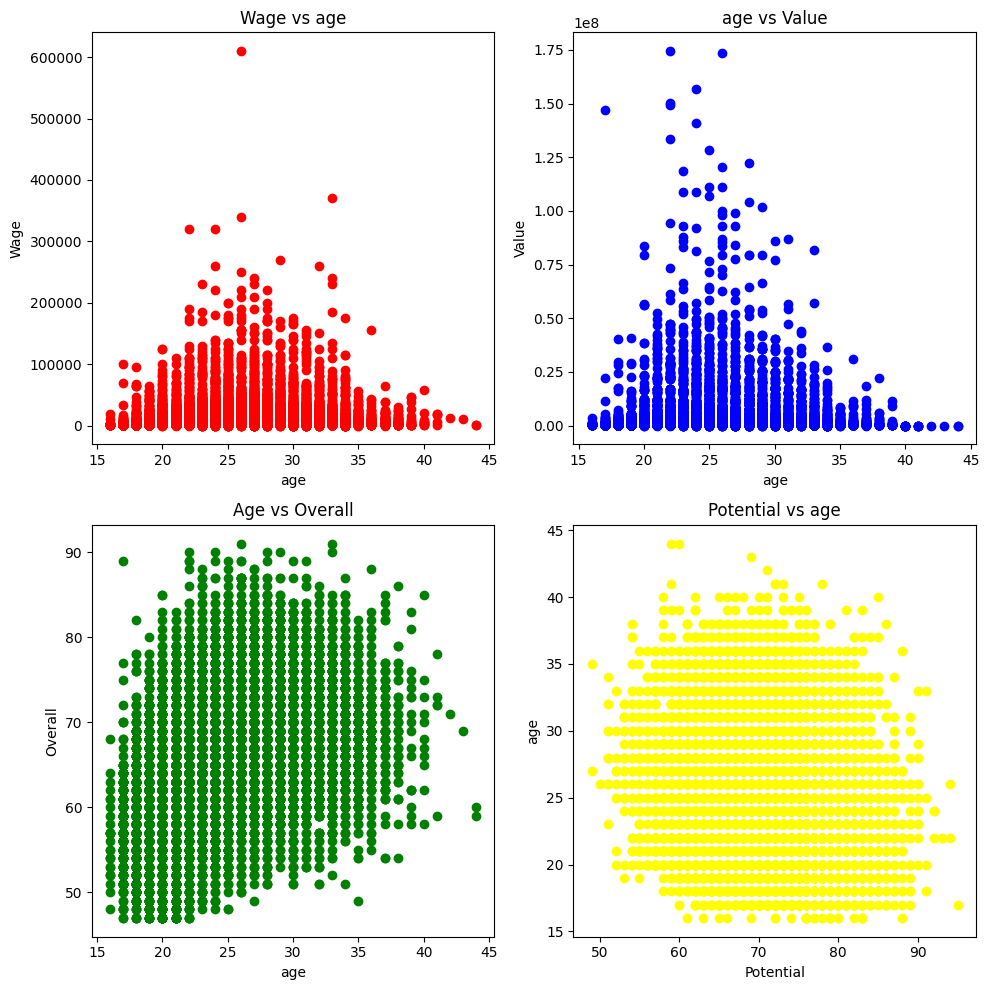

In [ ]:
plt.figure(figsize=(10,10))
plt.subplot(2,2,1)
plt.scatter(
    x=df_selected['age'],
    y=df_selected['wage_eur'],
    color='red'
)
plt.xlabel('age')
plt.ylabel('Wage')
plt.title('Wage vs age')

plt.subplot(2,2,2)
plt.scatter(
    x=df_selected['age'],
    y=df_selected['value_eur'],
    color='blue'
)
plt.xlabel('age')
plt.ylabel('Value')
plt.title('age vs Value')

plt.subplot(2,2,3)
plt.scatter(
    x=df_selected['age'],
    y=df_selected['overall'],
    color='green'
)
plt.xlabel('age')
plt.ylabel('Overall')
plt.title('Age vs Overall')

plt.subplot(2,2,4)
plt.scatter(
    y=df_selected['age'],
    x=df_selected['potential'],
    color='yellow'
)
plt.xlabel('Potential')
plt.ylabel('age')
plt.title('Potential vs age')

plt.tight_layout()
plt.show()

### Insights:
1. The player Overall ratings follow a near-perfect Normal Distribution (Bell Curve).
Business Translation: The vast majority of professional players fall into the average tier (ratings between 60 and 70). Conversely, "World-Class" elite talents (ratings 85+) are extremely rare statistical outliers. This highlights the difficulty and value of scouting top-tier players

2. The dataset is heavily concentrated around younger players, peaking between the ages of 20 and 24, followed by a sharp and steady decline after age 30
Business Translation: Football is overwhelmingly a youth-dominated sport.The rapid drop-off after age 30 reflects the natural physical decline of players and clubs' reluctance to keep older players on their rosters, emphasizing the need for continuous youth scouting

3. Both Market Value and Wages exhibit a severe Right-Skewed distribution.
Business Translation: There is extreme financial inequality in the football market. Over 90% of players command standard, relatively low wages and transfer values. However, a tiny 10% fraction of elite "Superstars" command astronomical, market-breaking salaries and transfer fees, stretching the tail of the distribution to the far right

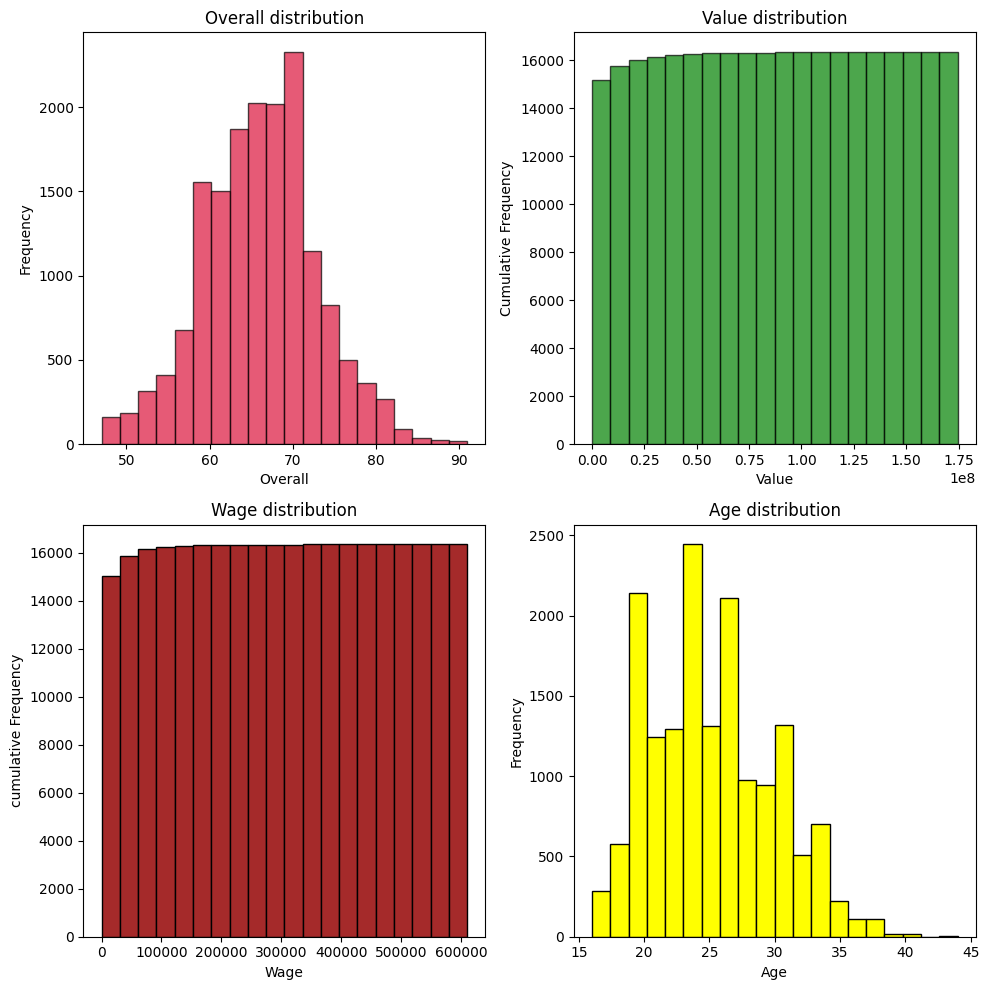

In [ ]:
plt.figure(figsize=(10,10))
plt.subplot(2,2,1)
plt.hist(
    x=df_selected['overall'],
    bins=20,
    color ='crimson',
    edgecolor='black',
    alpha=0.7,
)
plt.xlabel('Overall')
plt.ylabel('Frequency')
plt.title('Overall distribution')

plt.subplot(2,2,2)
plt.hist(
    x=df_selected['value_eur'],
    bins=20,
    color ='green',
    alpha=0.7,
    edgecolor='black',
    cumulative=True
)
plt.xlabel('Value')
plt.ylabel('Cumulative Frequency')
plt.title('Value distribution')

plt.subplot(2,2,3)
plt.hist(
    x=df_selected['wage_eur'],
    bins=20,
    color ='brown',
    edgecolor='black',
    cumulative=True
)
plt.xlabel('Wage')
plt.ylabel('cumulative Frequency')
plt.title('Wage distribution')

plt.subplot(2,2,4)
plt.hist(
    x=df_selected['age'],
    bins=20,
color ='yellow',
    edgecolor='black'
    )
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age distribution')

plt.tight_layout()
plt.show()

### Insights:
##### Free players have a better median value than other players even level 1
##### Level 1 Players have much outliers and theese represent Extraordinary players

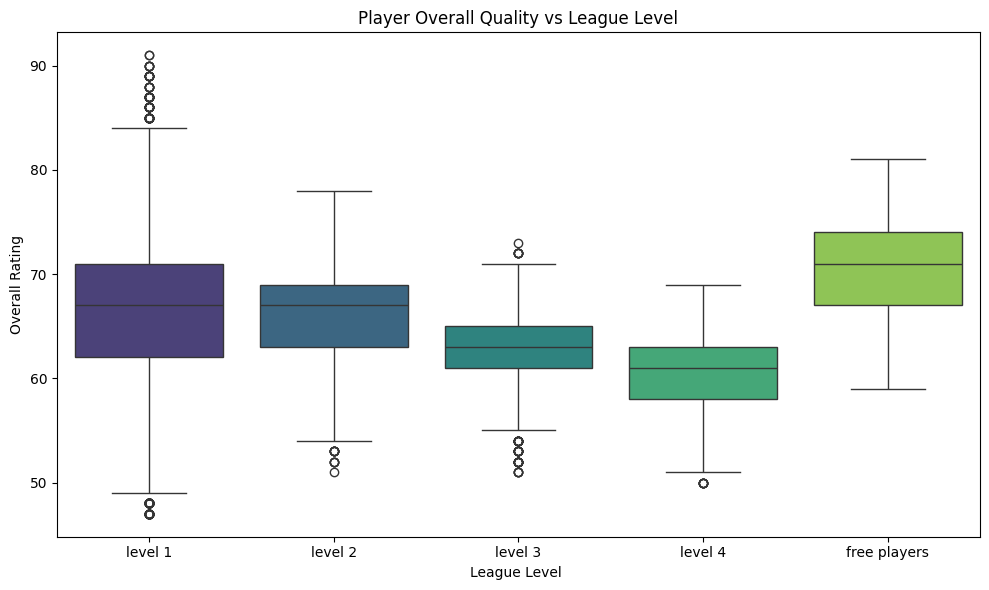

In [ ]:
df_leagues = df_selected[df_selected['league_level'].isin([1, 2, 3, 4,5])]
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_leagues, x='league_level', y='overall', palette='viridis')
plt.title('Player Overall Quality vs League Level')
plt.xlabel('League Level ')
plt.ylabel('Overall Rating')
plt.xticks([0,1,2,3,4],['level 1' , 'level 2' , 'level 3' , 'level 4' , 'free players'])
plt.tight_layout()
plt.show()

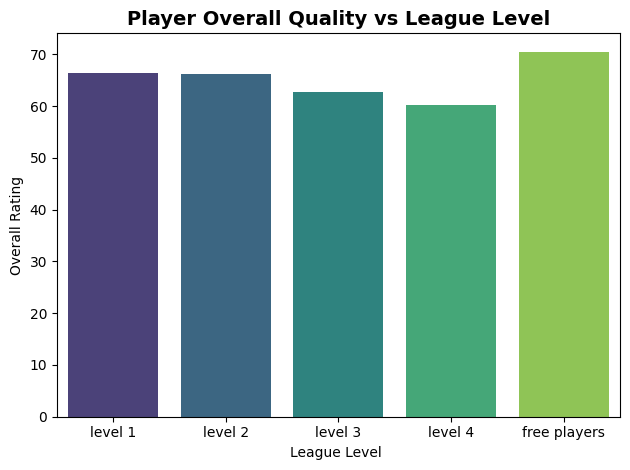

In [ ]:
sns.barplot(data=df_leagues, x='league_level', y='overall', palette='viridis' ,errorbar=None , estimator='mean')
plt.title('Player Overall Quality vs League Level' , fontsize=14 , fontweight='bold')
plt.xlabel('League Level ')
plt.ylabel('Overall Rating')
plt.xticks([0,1,2,3,4],['level 1' , 'level 2' , 'level 3' , 'level 4' , 'free players'])
plt.tight_layout()
plt.show()

In [ ]:
df_grouped_by_league_level = df_selected.groupby('league_level')
display(df_grouped_by_league_level[['overall']].agg(['max','min', 'mean', 'median', 'std']))
print("Data seems to be normally distributed")
print("also level 1 seems to have very high variance")

overall                                
                 max min       mean median       std
league_level                                        
1.0               91  47  66.447937   67.0  7.386669
2.0               78  51  66.188061   67.0  4.606759
3.0               73  51  62.774312   63.0  3.828567
4.0               69  50  60.331070   61.0  3.563429
5.0               81  59  70.558442   71.0  4.998667

Data seems to be normally distributed
also level 1 seems to have very high variance


### Insight:
##### we can notice that players with right foot are much more than left foot
##### high percentage of players with right foot tend to have positions: CM , ST , CB , RB
##### high percentage of players with left foot tend to have positions: CB , LB
##### there is high percentage of players in CB position
##### We need foot type in our classification task

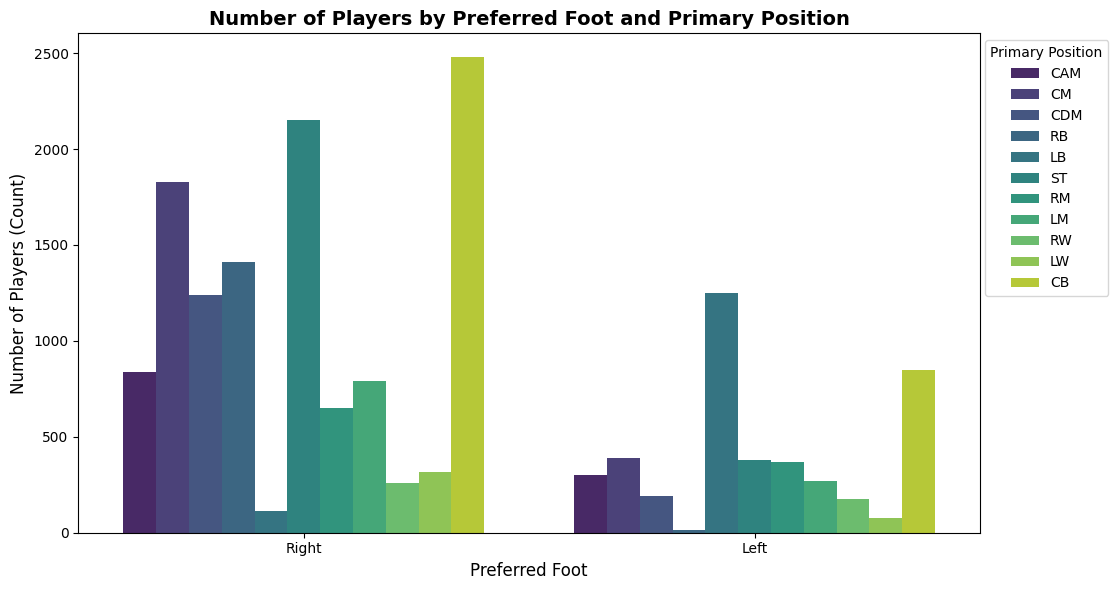

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(
    x='preferred_foot',
    data=df_selected,
    hue='primary_position',
    palette='viridis'

)
plt.title('Number of Players by Preferred Foot and Primary Position', fontsize=14, fontweight='bold')
plt.xlabel('Preferred Foot', fontsize=12)
plt.ylabel('Number of Players (Count)', fontsize=12)
plt.tight_layout()
plt.legend(loc='upper right', title='Primary Position', bbox_to_anchor=(1.15, 1))
plt.show()

In [ ]:
df_selected['preferred_foot']=df_selected['preferred_foot'].map({'Left':0 , 'Right':1} )

### Inspecting relations

### Insight:
1. The "Creative Attacker" Synergy
Attacking skills (Passing, Dribbling, Shooting) are heavily interlinked. An elite dribbler is almost always a complete offensive threat and playmaker.

2. The Defensive Trade-off
High defensive ability guarantees physical strength but sacrifices pace and shooting, clearly defining the traditional "Physical Bruiser" archetype.

3. Technique Dictates Quality & Value
Football IQ and technical skills (Passing/Dribbling) are the ultimate drivers of a player's Overall Rating and Market Value. Pure speed (Pace) is relatively cheap and highly overrated.

4. The Premium on Potential
The transfer market heavily prices in "Growth Room." A player's future potential drives their market value almost as much as their current overall ability.

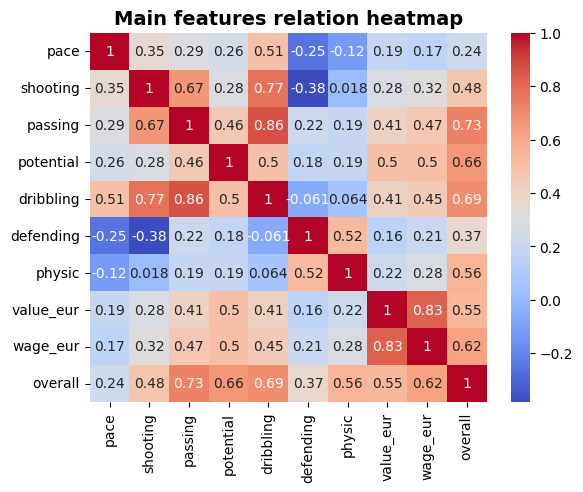

In [ ]:
cols_to_discover=['pace', 'shooting',
       'passing', 'potential' ,'dribbling', 'defending', 'physic' , 'value_eur', 'wage_eur' , 'overall' ]
df_to_discover=df[cols_to_discover]
sns.heatmap(
    df_to_discover.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title('Main features relation heatmap' , fontsize= 14 , fontweight='bold')
plt.show()

### Insights:
1. Brain Over Brawn:
Mental speed (Reactions & Composure) dictates a player's world-class status far more than pure physical speed.

2. The PCA Mandate (Data Overlap):
Defensive stats (tackling, marking) are over 95% correlated. We must compress these redundant features using PCA to prevent our AI from being biased toward defenders.

3. Technique is Expensive :
Tight ball control and dribbling are the most financially valued micro-skills in the transfer market.

4. Muscle is Cheap :
Raw physical traits (Strength & Stamina) have almost zero impact on driving up a player’s overall rating or market price.

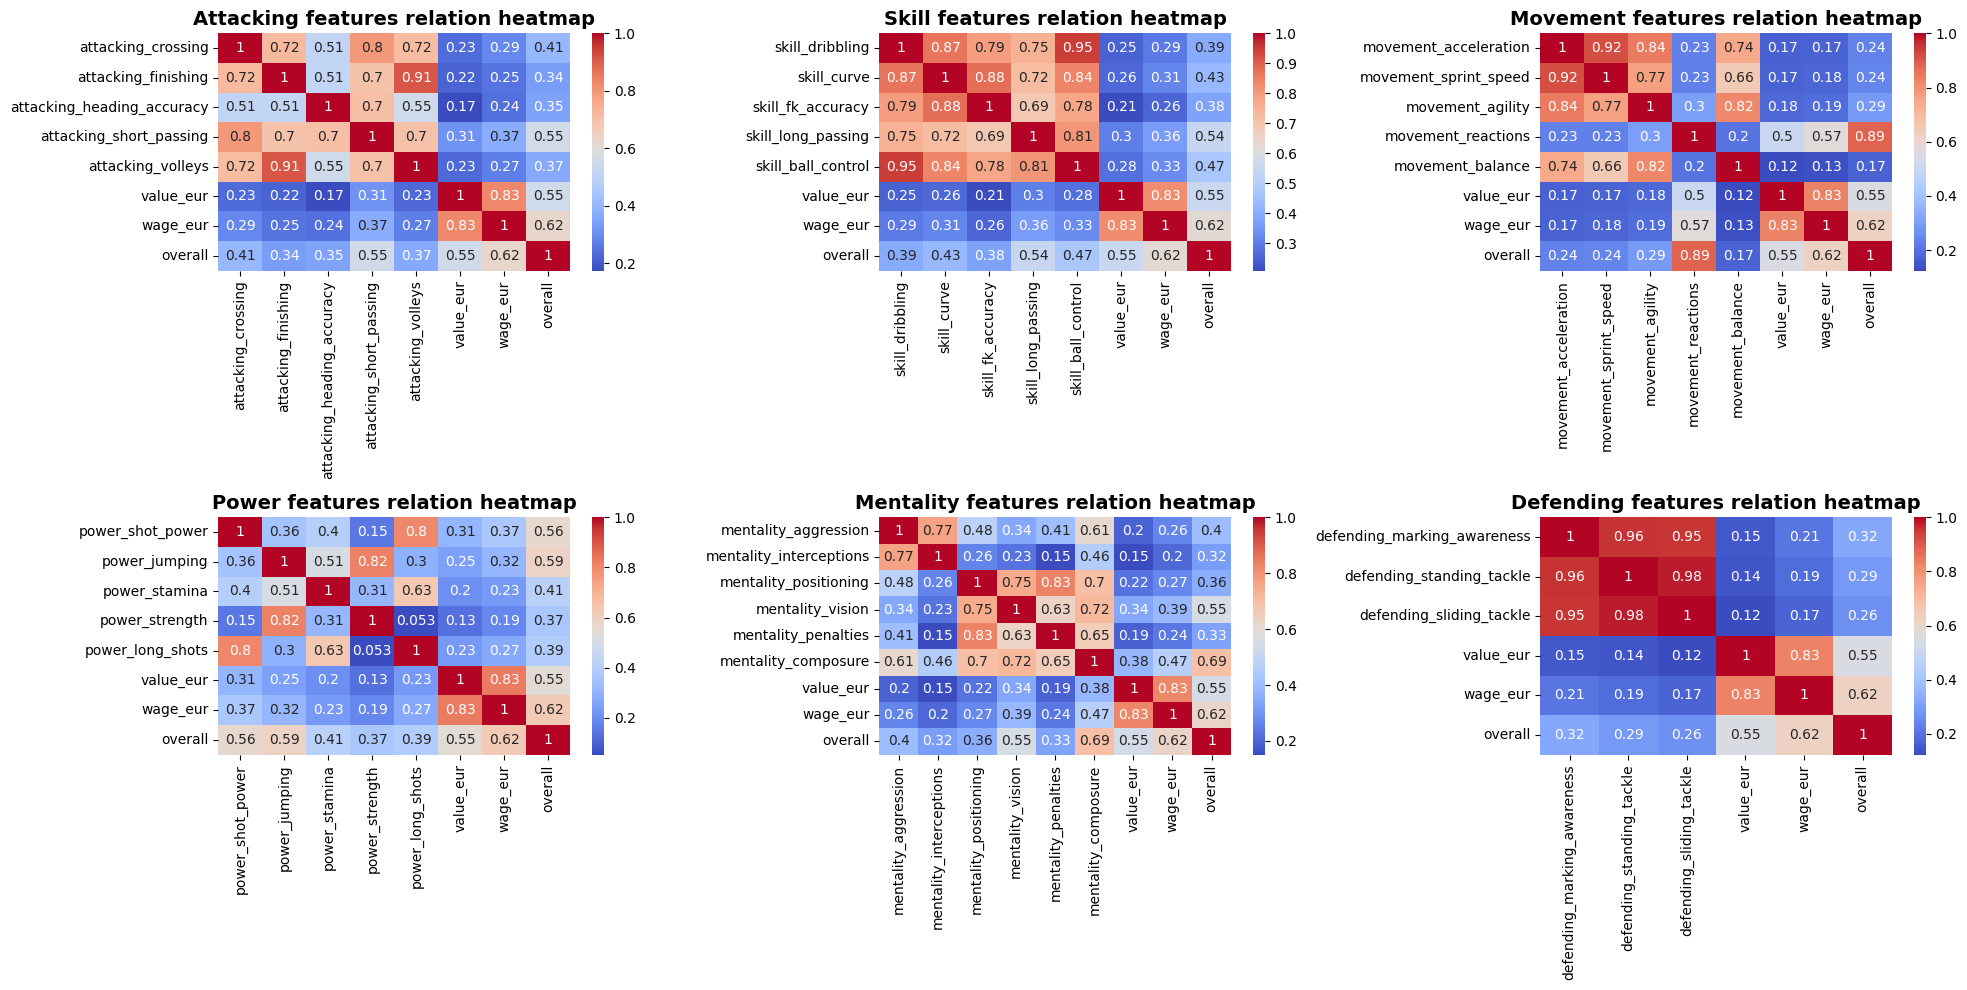

In [ ]:
plt.figure(figsize=(20,10) )
plt.subplot(2,3,1)
cols_to_discover=[ 'attacking_crossing',
       'attacking_finishing', 'attacking_heading_accuracy',
       'attacking_short_passing', 'attacking_volleys','value_eur', 'wage_eur' , 'overall' ]
df_to_discover=df[cols_to_discover]
sns.heatmap(
    df_to_discover.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title('Attacking features relation heatmap' , fontsize= 14 , fontweight='bold')

plt.subplot(2,3,2)
cols_to_discover=[ 'skill_dribbling', 'skill_curve', 'skill_fk_accuracy',
       'skill_long_passing', 'skill_ball_control','value_eur', 'wage_eur' , 'overall' ]
df_to_discover=df[cols_to_discover]
sns.heatmap(
    df_to_discover.corr(),
    annot=True,
    cmap='coolwarm')
plt.title('Skill features relation heatmap' , fontsize=14 , fontweight='bold')

plt.subplot(2,3,3)
cols_to_discover=[ 'movement_acceleration', 'movement_sprint_speed',
       'movement_agility', 'movement_reactions', 'movement_balance','value_eur', 'wage_eur' , 'overall' ]
df_to_discover=df[cols_to_discover]
sns.heatmap(
    df_to_discover.corr(),
    annot=True,
    cmap='coolwarm')
plt.title('Movement features relation heatmap', fontsize= 14 , fontweight='bold')

plt.subplot(2,3,4)
cols_to_discover=[ 'power_shot_power', 'power_jumping', 'power_stamina',
       'power_strength', 'power_long_shots','value_eur', 'wage_eur' , 'overall' ]
df_to_discover=df[cols_to_discover]
sns.heatmap(
    df_to_discover.corr(),
    annot=True,
    cmap='coolwarm')
plt.title('Power features relation heatmap', fontsize= 14 , fontweight='bold')

plt.subplot(2,3,5)
cols_to_discover=[ 'mentality_aggression', 'mentality_interceptions','mentality_positioning',
       'mentality_vision', 'mentality_penalties', 'mentality_composure','value_eur', 'wage_eur' , 'overall' ]
df_to_discover=df[cols_to_discover]
sns.heatmap(
    df_to_discover.corr(),
    annot=True,
    cmap='coolwarm')
plt.title('Mentality features relation heatmap', fontsize= 14 , fontweight='bold')

plt.subplot(2,3,6)
cols_to_discover=[ 'defending_marking_awareness', 'defending_standing_tackle',
       'defending_sliding_tackle','value_eur', 'wage_eur' , 'overall' ]
df_to_discover=df[cols_to_discover]
sns.heatmap(
    df_to_discover.corr(),
    annot=True,
    cmap='coolwarm')
plt.title('Defending features relation heatmap', fontsize= 14 , fontweight='bold')
plt.tight_layout()


plt.show()

#### Scaling data

In [ ]:
main_ml_columns = [
    'age', 'height_cm', 'weight_kg',
    'overall', 'potential',
    'pace', 'shooting', 'passing', 'dribbling', 'defending', 'physic',
    'weak_foot', 'skill_moves', 'international_reputation',
    'preferred_foot'
]

sub_ml_columns = [
    # Attacking
    'attacking_crossing', 'attacking_finishing', 'attacking_heading_accuracy',
    'attacking_short_passing', 'attacking_volleys',
    # Skill
    'skill_dribbling', 'skill_curve', 'skill_fk_accuracy',
    'skill_long_passing', 'skill_ball_control',
    # Movement
    'movement_acceleration', 'movement_sprint_speed', 'movement_agility',
    'movement_reactions', 'movement_balance',
    # Power
    'power_shot_power', 'power_jumping', 'power_stamina',
    'power_strength', 'power_long_shots',
    # Mentality
    'mentality_aggression', 'mentality_interceptions', 'mentality_positioning',
    'mentality_vision', 'mentality_penalties', 'mentality_composure',
    # Defending
    'defending_marking_awareness', 'defending_standing_tackle', 'defending_sliding_tackle'
]

money=['value_eur', 'wage_eur']
money_df=df_selected[money]

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
features_to_scale = main_ml_columns + sub_ml_columns
df_selected[features_to_scale]=scaler.fit_transform(df_selected[features_to_scale])

## PCA


In [ ]:
df_main_ml=df_selected[main_ml_columns]
df_sub_ml=df_selected[sub_ml_columns]

### PCA EVR

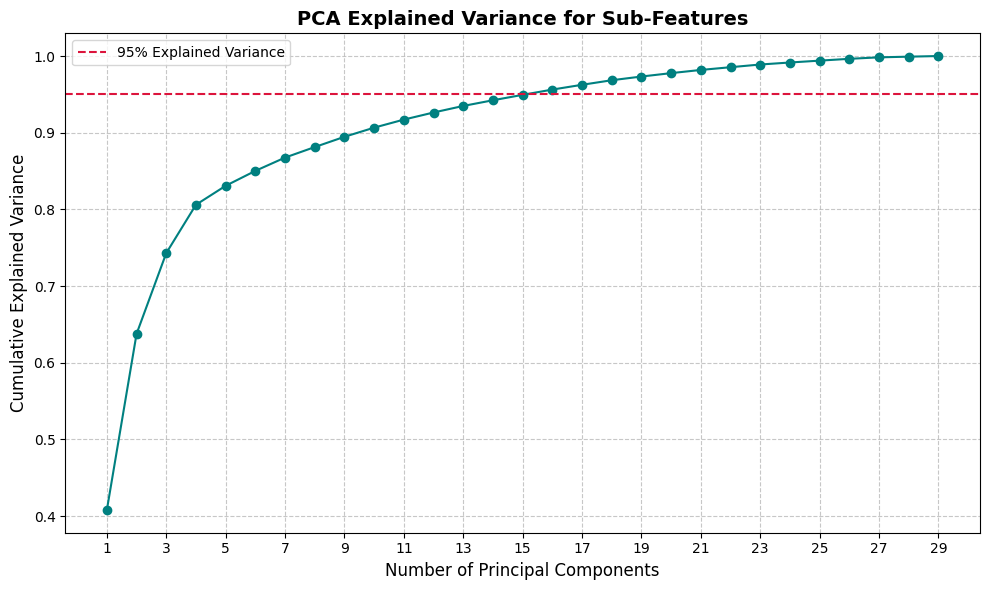

Total original sub-features: 29
Number of components needed to retain 95% of information: 16


In [ ]:
pca = PCA()
pca.fit(df_sub_ml)

cumsum = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 6))

plt.plot(range(1, len(cumsum) + 1), cumsum, marker='o', linestyle='-', color='teal')
plt.axhline(y=0.95, color='crimson', linestyle='--', label='95% Explained Variance')

plt.xlabel('Number of Principal Components', fontsize=12)
plt.ylabel('Cumulative Explained Variance', fontsize=12)
plt.title('PCA Explained Variance for Sub-Features', fontsize=14, fontweight='bold')
plt.xticks(range(1, len(cumsum) + 1, 2))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

d_95 = np.argmax(cumsum >= 0.95) + 1
print(f"Total original sub-features: {df_sub_ml.shape[1]}")
print(f"Number of components needed to retain 95% of information: {d_95}")

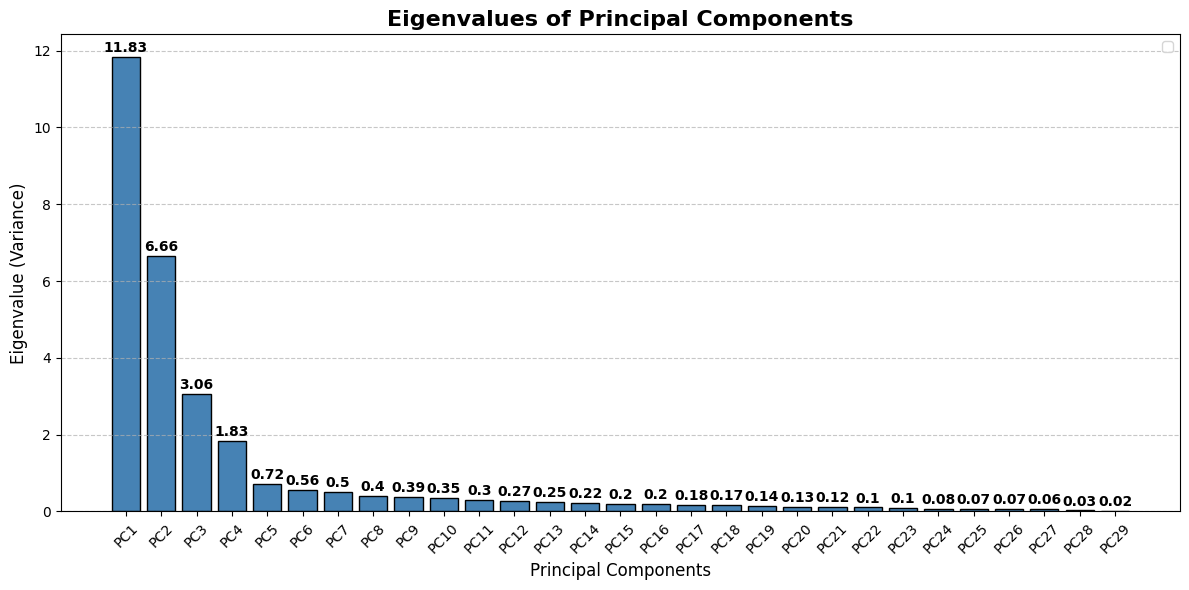

In [ ]:
eigenvalues = pca.explained_variance_
num_components = len(eigenvalues)

pc_labels = [f'PC{i}' for i in range(1, num_components + 1)]

plt.figure(figsize=(12, 6))

bars = plt.bar(pc_labels, eigenvalues, color='steelblue', edgecolor='black')

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 0.05,
        round(yval, 2),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.title('Eigenvalues of Principal Components', fontsize=16, fontweight='bold')
plt.xlabel('Principal Components', fontsize=12)
plt.ylabel('Eigenvalue (Variance)', fontsize=12)
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### We will use 16 PC to retain 95% of Inormation

In [ ]:
pca_final = PCA(n_components=d_95, random_state=42)
sub_features_pca = pca_final.fit_transform(df_sub_ml)


pca_columns = [f'PC{i+1}' for i in range(d_95)]
df_pca = pd.DataFrame(sub_features_pca, columns=pca_columns, index=df_main_ml.index)

df_final_ml = pd.concat([df_main_ml, df_pca], axis=1)

print(f" We used {d_95} components.")
print(f"Final shape of our Machine Learning Dataset: {df_final_ml.shape}")
display(df_final_ml.head(3))

 We used 16 components.
Final shape of our Machine Learning Dataset: (16343, 31)


,age,height_cm,weight_kg,overall,potential,pace,shooting,passing,dribbling,defending,...,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16
0,-0.664321,0.747917,0.097298,3.502025,3.567041,1.105652,2.381111,2.563169,2.889956,1.608325,...,-0.321953,0.667487,-0.482127,-0.991096,-0.253225,-0.423659,0.632114,0.251723,0.024542,-0.169171
1,0.195605,0.138911,-0.054607,3.356344,2.936760,1.866460,2.237626,2.664129,2.250553,1.917050,...,0.884502,1.338934,-0.800159,-1.196690,0.366533,-0.913475,-0.233576,-0.001689,0.010930,-0.430050
2,1.055531,-0.622346,0.097298,3.356344,2.779189,0.344844,1.520202,3.168927,2.250553,1.917050,...,-0.601270,-0.561659,0.186193,-0.243001,0.098856,0.592335,-0.001558,0.170156,0.079286,-0.102924


### 1.  Modeling

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

#### Random Forset

In [ ]:
accuracies = []

y = df_meta['player_positions'].apply(lambda x: str(x).split(',')[0].strip())
X = df_final_ml
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf_classifier = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    max_depth = 25,
    min_samples_split = 5,
    min_samples_leaf = 2,
    class_weight='balanced'
)

rf_classifier.fit(X_train, y_train)

y_pred = rf_classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)*100

accuracies.append(accuracy)

print(f"Overall Classification Accuracy: {accuracy :.2f}%")

print("\n Classification Report:\n")
print(classification_report(y_test, y_pred))

Overall Classification Accuracy: 72.16%

 Classification Report:

              precision    recall  f1-score   support

         CAM       0.51      0.53      0.52       227
          CB       0.93      0.92      0.92       665
         CDM       0.64      0.64      0.64       287
          CM       0.66      0.76      0.71       443
          LB       0.84      0.87      0.86       273
          LM       0.35      0.35      0.35       213
          LW       0.31      0.11      0.17        79
          RB       0.76      0.84      0.80       285
          RM       0.38      0.33      0.35       203
          RW       0.39      0.21      0.27        87
          ST       0.89      0.91      0.90       507

    accuracy                           0.72      3269
   macro avg       0.61      0.59      0.59      3269
weighted avg       0.71      0.72      0.71      3269



In [ ]:
df_unscaled=scaler.inverse_transform(df_selected[features_to_scale])


In [ ]:
df_unscaled=pd.DataFrame(df_unscaled , columns=features_to_scale)
df_unscaled=df_unscaled.join(df_meta['long_name'])


### SVM

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score

from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score


svm_model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    random_state=42,
    class_weight='balanced'
)


svm_model.fit(X_train, y_train)


print("\nAfter Testing SVM on Unseen Test Data")
y_pred_svm = svm_model.predict(X_test)
final_svm_accuracy = accuracy_score(y_test, y_pred_svm) * 100

accuracies.append(final_svm_accuracy)
print(f" Final SVM Test Accuracy: {final_svm_accuracy:.2f}%\n")
print("SVM Classification Report:\n")
print(classification_report(y_test, y_pred_svm, zero_division=0))


After Testing SVM on Unseen Test Data
 Final SVM Test Accuracy: 75.53%

SVM Classification Report:

              precision    recall  f1-score   support

         CAM       0.59      0.62      0.60       227
          CB       0.95      0.92      0.93       665
         CDM       0.79      0.74      0.76       287
          CM       0.79      0.87      0.83       443
          LB       0.89      0.86      0.88       273
          LM       0.36      0.35      0.35       213
          LW       0.16      0.20      0.18        79
          RB       0.78      0.87      0.83       285
          RM       0.42      0.32      0.36       203
          RW       0.28      0.34      0.31        87
          ST       0.94      0.89      0.91       507

    accuracy                           0.76      3269
   macro avg       0.63      0.63      0.63      3269
weighted avg       0.76      0.76      0.76      3269



## BOOSTING

## Adaboost

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

base_tree = DecisionTreeClassifier(max_depth=2, random_state=42)

ada_model = AdaBoostClassifier(
    estimator=base_tree,
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    algorithm='SAMME'
)

ada_model.fit(X_train, y_train)

y_pred_ada = ada_model.predict(X_test)
ada_accuracy = accuracy_score(y_test, y_pred_ada)*100

accuracies.append(ada_accuracy)

print(f" Final AdaBoost Test Accuracy: {ada_accuracy :.2f}%")

print("\n AdaBoost Classification Report:\n")
print(classification_report(y_test, y_pred_ada, zero_division=0))

 Final AdaBoost Test Accuracy: 58.98%

 AdaBoost Classification Report:

              precision    recall  f1-score   support

         CAM       0.39      0.33      0.36       227
          CB       0.70      0.91      0.79       665
         CDM       0.53      0.32      0.40       287
          CM       0.45      0.70      0.55       443
          LB       0.74      0.66      0.70       273
          LM       0.30      0.51      0.38       213
          LW       0.00      0.00      0.00        79
          RB       0.68      0.32      0.43       285
          RM       0.18      0.06      0.09       203
          RW       0.00      0.00      0.00        87
          ST       0.82      0.90      0.86       507

    accuracy                           0.59      3269
   macro avg       0.44      0.43      0.41      3269
weighted avg       0.56      0.59      0.55      3269



#### LightGBM

In [ ]:
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)


lgb_model = lgb.LGBMClassifier(
    objective='multiclass',
    n_estimators=200,
    learning_rate=0.05,
    max_depth=7,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)


print("Training LightGBM (Watch how fast this is!)... \n")
lgb_model.fit(X_train, y_train_encoded)


y_pred_lgb_encoded = lgb_model.predict(X_test)
lgb_accuracy = accuracy_score(y_test_encoded, y_pred_lgb_encoded)*100

accuracies.append(lgb_accuracy)

print(f"Final LightGBM Test Accuracy: {lgb_accuracy * 100:.2f}%")



y_pred_lgb_names = label_encoder.inverse_transform(y_pred_lgb_encoded)

print("\n Detailed LightGBM Classification Report:\n")
print(classification_report(y_test, y_pred_lgb_names, zero_division=0))

Training LightGBM (Watch how fast this is!)... 

Final LightGBM Test Accuracy: 7363.11%

 Detailed LightGBM Classification Report:

              precision    recall  f1-score   support

         CAM       0.55      0.52      0.53       227
          CB       0.96      0.93      0.94       665
         CDM       0.68      0.72      0.70       287
          CM       0.71      0.77      0.74       443
          LB       0.88      0.86      0.87       273
          LM       0.34      0.36      0.35       213
          LW       0.20      0.11      0.14        79
          RB       0.81      0.91      0.85       285
          RM       0.36      0.31      0.33       203
          RW       0.27      0.25      0.26        87
          ST       0.90      0.90      0.90       507

    accuracy                           0.74      3269
   macro avg       0.60      0.60      0.60      3269
weighted avg       0.73      0.74      0.73      3269



## XGBOOST

In [ ]:
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)


xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(label_encoder.classes_),
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.5,
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)


xgb_model.fit(X_train, y_train_encoded)


y_pred_xgb_encoded = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test_encoded, y_pred_xgb_encoded)*100

accuracies.append(xgb_accuracy)

print(f" Final XGBoost Test Accuracy: {xgb_accuracy :.2f}%")

y_pred_xgb_names = label_encoder.inverse_transform(y_pred_xgb_encoded)

print("\n XGBoost Classification Report:\n")
print(classification_report(y_test, y_pred_xgb_names, zero_division=0))

## Catboost

In [ ]:
!pip install catboost
from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, accuracy_score




cat_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=6,
    loss_function='MultiClass',
    auto_class_weights='Balanced',
    random_seed=42,
    verbose=0
)


cat_model.fit(X_train, y_train_encoded)


y_pred_cat_encoded = cat_model.predict(X_test)


y_pred_cat_encoded = y_pred_cat_encoded.flatten()


cat_accuracy = accuracy_score(y_test_encoded, y_pred_cat_encoded)*100

accuracies.append(cat_accuracy)

print(f" Final CatBoost Test Accuracy: {cat_accuracy :.2f}%")



y_pred_cat_names = label_encoder.inverse_transform(y_pred_cat_encoded)

print("\n Detailed CatBoost Classification Report:\n")
print(classification_report(y_test, y_pred_cat_names, zero_division=0))

In [ ]:
model_names = ['Random Forest', 'SVM', 'adaboost', 'lightGBM','Catboost','XGBoost']

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=model_names, y=accuracies, palette='mako')


for p in ax.patches:
    ax.annotate(f'{p.get_height() :.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 10),
                textcoords='offset points',
                fontsize=12, fontweight='bold', color='#333333')


plt.title('Models Accuracy Comparison (Before Mapping)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Machine Learning Models', fontsize=14, labelpad=10)
plt.ylabel('Accuracy Score', fontsize=14, labelpad=10)




plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
accuracies

## XGBOOST

In [ ]:
new_accuracies=[]

def group_positions(pos):
    pos = str(pos).split(',')[0].strip()

    if pos in ['LW', 'RW', 'LM', 'RM']:
        return 'Wingers/Wide Mid'
    elif pos in ['CAM', 'CM', 'CDM']:
        return 'Central Midfielders'

    else:
        return pos


y_grouped = df_meta['player_positions'].apply(group_positions)


label_encoder_g = LabelEncoder()
y_encoded_g = label_encoder_g.fit_transform(y_grouped)

print("\n New Target Classes:")
print(label_encoder_g.classes_)


X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
    X, y_encoded_g, test_size=0.2, random_state=42, stratify=y_encoded_g
)

print("\nTraining XGBoost on Grouped Positions")
xgb_grouped = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(label_encoder_g.classes_),
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)

xgb_grouped.fit(X_train_g, y_train_g)


y_pred_g_encoded = xgb_grouped.predict(X_test_g)
grouped_accuracy = accuracy_score(y_test_g, y_pred_g_encoded)


print(f" XGBoost Accuracy with Grouped Positions: {grouped_accuracy * 100:.2f}%")

y_pred_g_names = label_encoder_g.inverse_transform(y_pred_g_encoded)
y_test_g_names = label_encoder_g.inverse_transform(y_test_g)

print("\n Classification Report:\n")
print(classification_report(y_test_g_names, y_pred_g_names, zero_division=0))

## KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score



knn_base = KNeighborsClassifier()


param_grid_knn = {
    'n_neighbors': [5, 9, 15, 25],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_search_knn = GridSearchCV(
    estimator=knn_base,
    param_grid=param_grid_knn,
    cv=3,
    n_jobs=-1,
    scoring='accuracy',
    verbose=1
)


grid_search_knn.fit(X_train_g, y_train_g)


best_knn = grid_search_knn.best_estimator_


print(f" Best Parameters Found: {grid_search_knn.best_params_}")


y_pred_knn_encoded = best_knn.predict(X_test_g)
knn_accuracy = accuracy_score(y_test_g, y_pred_knn_encoded)

print(f"\n Final KNN Accuracy: {knn_accuracy * 100:.2f}%\n")


y_pred_knn_names = label_encoder_g.inverse_transform(y_pred_knn_encoded)


print("KNN Classification Report:\n")
print(classification_report(y_test_g_names, y_pred_knn_names, zero_division=0))

## جزء الUNSUPERVISED

### K-means

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

k_range = range(2, 16)

silhouette_scores = []
best_score = -1
best_k = -1
best_model = None



for k in k_range:

    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, max_iter=300, random_state=42)


    cluster_labels = kmeans.fit_predict(df_final_ml)


    score = silhouette_score(df_final_ml, cluster_labels)
    silhouette_scores.append(score)

    print(f"Tested K = {k:2d} | Silhouette Score = {score:.4f}")


    if score > best_score:
        best_score = score
        best_k = k
        best_model = kmeans

print("-" * 40)
print(f" Optimal Number of Clusters (K): {best_k}")
print(f" Best Silhouette Score: {best_score:.4f}")


plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, marker='o', linestyle='-', color='indigo', linewidth=2)
plt.axvline(x=best_k, color='crimson', linestyle='--', label=f'Optimal K = {best_k}')
plt.title('K-Means Grid Search: Silhouette Score Optimization', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.xticks(k_range)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

df_final_ml['Cluster'] = best_model.labels_


df_meta['Cluster'] = best_model.labels_

### GMM

In [ ]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=12, random_state=43, covariance_type='full')

cluster_labels = gmm.fit_predict(df_final_ml)

probabilities = gmm.predict_proba(df_final_ml)

confidence_scores = probabilities.max(axis=1)

df_meta['GMM_Playstyle'] = cluster_labels
df_meta['Style_Confidence_%'] = np.round(confidence_scores * 100, 2)

display(df_meta[['short_name', 'GMM_Playstyle', 'Style_Confidence_%']].sample(10))

In [ ]:
plt.hist(
    x=df_meta['Style_Confidence_%'],
    bins=12,
    color ='crimson',
    edgecolor='black',
    alpha=0.7,
)
plt.show()

In [ ]:
n_components_range = range(2, 16)

aic_scores = []
bic_scores = []


for n in n_components_range:
    gmm = GaussianMixture(n_components=n, covariance_type='tied', random_state=42)
    gmm.fit(df_final_ml)

    aic_scores.append(gmm.aic(df_final_ml))
    bic_scores.append(gmm.bic(df_final_ml))


plt.figure(figsize=(10, 6))
plt.plot(n_components_range, bic_scores, label='BIC (Bayesian)', marker='o', color='teal', linewidth=2)
plt.plot(n_components_range, aic_scores, label='AIC (Akaike)', marker='s', color='crimson', linewidth=2, linestyle='--')

plt.title('GMM Model Selection: AIC & BIC Scores', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Information Criterion Score (Lower is Better)', fontsize=12)
plt.xticks(n_components_range)
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



In [ ]:
gmm_soft_v2 = GaussianMixture(
    n_components=18,
    covariance_type='spherical',
    reg_covar=0.01,
    random_state=42
)

cluster_labels = gmm_soft_v2.fit_predict(df_final_ml)


probabilities = gmm_soft_v2.predict_proba(df_final_ml)
confidence_scores = probabilities.max(axis=1) * 100


df_meta['GMM_Playstyle'] = cluster_labels
df_meta['Style_Confidence_%'] = np.round(confidence_scores, 2)


plt.figure(figsize=(8, 5))
plt.hist(confidence_scores, bins=20, color='mediumseagreen', edgecolor='black', alpha=0.8)
plt.title('Final GMM Confidence Scores (Spherical + High Reg)', fontsize=14, fontweight='bold')
plt.xlabel('Confidence Score (%)', fontsize=12)
plt.ylabel('Number of Players', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
def scout_similar_players(player_name, num_results=10):
    """
   Similarity Score
    """
    player_idx = df_meta[df_meta['short_name'].str.contains(player_name, case=False, na=False)].index

    if len(player_idx) == 0:
        return f"can not find a player with this name {player_name}"

    target_idx = player_idx[0]
    full_name = df_meta.loc[target_idx, 'short_name']

    print(f" finding ... : {full_name}...\n")

    player_features = df_final_ml.loc[target_idx].values.reshape(1, -1)


    distances, indices = knn_engine.kneighbors(player_features, n_neighbors=num_results+1)

    results_df = df_meta.iloc[indices[0][1:]].copy()


    raw_similarities = 1 - distances[0][1:]


    results_df['Similarity_Score'] = np.round(raw_similarities * 100, 2)

    display_cols = ['short_name', 'player_positions',  'Similarity_Score']

    return results_df[display_cols]


display(scout_similar_players("de ligt", num_results=11))

### regression (Uncompleted model)

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score


y_potential = df_meta['potential'].values


X_barebone = df_final_ml[['age', 'overall']].values

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_barebone, y_potential, test_size=0.2, random_state=42
)

xgb_barebone = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)

xgb_barebone.fit(X_train_b, y_train_b)

y_pred_b = xgb_barebone.predict(X_test_b)

r2_b = r2_score(y_test_b, y_pred_b)
mae_b = mean_absolute_error(y_test_b, y_pred_b)


print(f" RAW XGBoost Results (Potential Prediction):")
print(f" R-squared on Test Set: {r2_b * 100:.2f}%")


## GUI

In [ ]:
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(pca_final, 'pca_final.pkl')
joblib.dump(xgb_grouped, 'xgb_model.pkl')
joblib.dump(label_encoder_g, 'label_encoder.pkl')
